# Generating surface plots of a single cortical hemisphere

This notebook is a tutorial for generating visualisations of a single cortical surface hemisphere using `plotting_pyvista.plot_surf`.

In [1]:
from importlib.resources import files
import matplotlib.pyplot as plt
import nibabel as nib
from neuromodes.io import fetch_surf
from neuromodes import EigenSolver
from nsbutils.utils import unmask
from nsbutils.plotting_pyvista import plot_surf

In [2]:
import pyvista as pv
pv.set_jupyter_backend("static")    # comment out for interactive plotting

We start by loading the necessary surfaces, and medial masks.

In [3]:
species = 'human'
den = "32k"

surf_lh_data, medmask_lh = fetch_surf(density=den, hemi="L", species=species)
surf_lh = {"vertices": surf_lh_data.vertices, "faces": surf_lh_data.faces}

We can calculate geometrice eigenmodes to use as data to plot on the surfaces.

In [4]:
solver_lh = EigenSolver(surf_lh, medmask_lh)
solver_lh.solve(n_modes=100)

modes_unmasked = unmask(solver_lh.emodes, medmask_lh)

Now we can plot the first non-constant eigenmode as an interactive plot. If you spin the surface around you'll notice that the medial wall is grey. This is handled by `rois` where any vertex labelled with `0` is greyed-out.

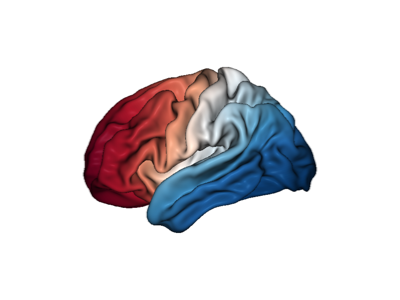

In [5]:
surfs = {"lh": surf_lh}
data = {"lh": modes_unmasked[:, 1]}
rois = {"lh": medmask_lh}

p = plot_surf(surfs, data=data, rois=rois, zoom=1, cmap="RdBu")
p.enable_anti_aliasing("ssaa")
p.show()

We can optionally plot the mesh edges, add a colobar, and adjust the size.

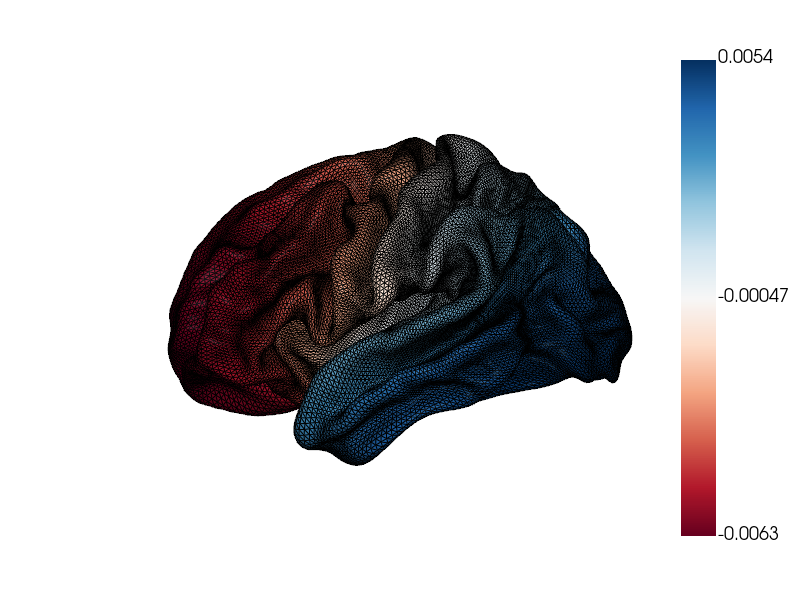

In [6]:
p = plot_surf(
    surfs, data=data, rois=rois, zoom=1, cmap="RdBu", mesh_edges=True, cbar=True, size=(800, 600)
)
p.show()

We can also plot multiple views. Note that the order of the views is determined by how they are ordered in views.

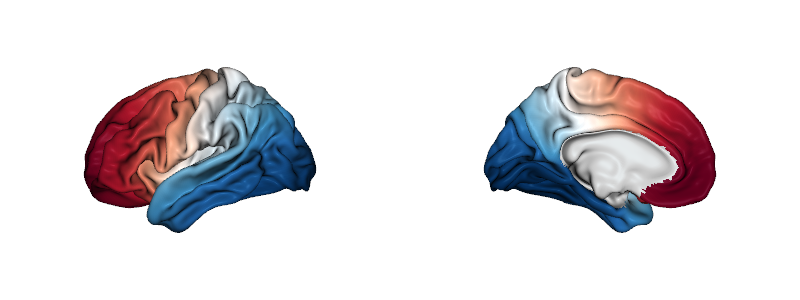

In [7]:
p = plot_surf(
    surfs, data=data, rois=rois, cmap="RdBu", views=["lateral", "medial"]
)
p.show()

We can also plot a parcellation by inputting it into rois and setting roi_outline=True. Zeros will again be masked out.

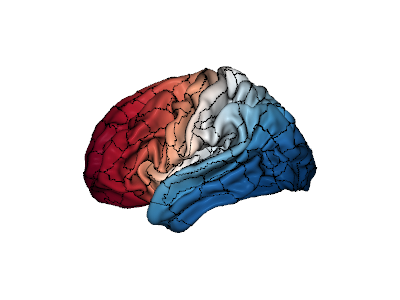

In [8]:
parc_lh_data = files('nsbutils').parent / 'docs' / 'tutorials' / 'tutorial_data' / 'Q1-Q6_RelatedParcellation210.L.CorticalAreas_dil_Colors.32k_fs_LR.label.gii'
parc_lh = nib.load(parc_lh_data).darrays[0].data.astype(int)
rois_parc = {"lh": parc_lh}

p = plot_surf(
    surfs, data=data, rois=rois_parc, cmap="RdBu", views=["lateral"], roi_outlines=True
)
p.show()

Alternatively if `data` has the same number of elements as the number of unique values in `rois`, data is plotted ROI-wise.

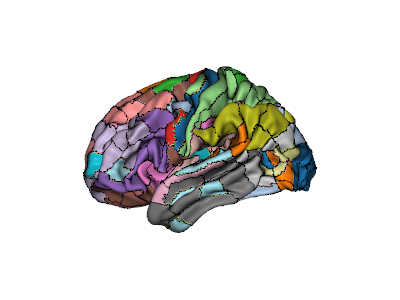

In [9]:
p = plot_surf(
    surfs, data=rois_parc, rois=rois_parc, cmap="tab20", views=["lateral"], roi_outlines=True
)
p.show()

We can plot multiple maps by redifining surfs["lh"] to be a 2D array. Note that size adjusts the size of each subplot.

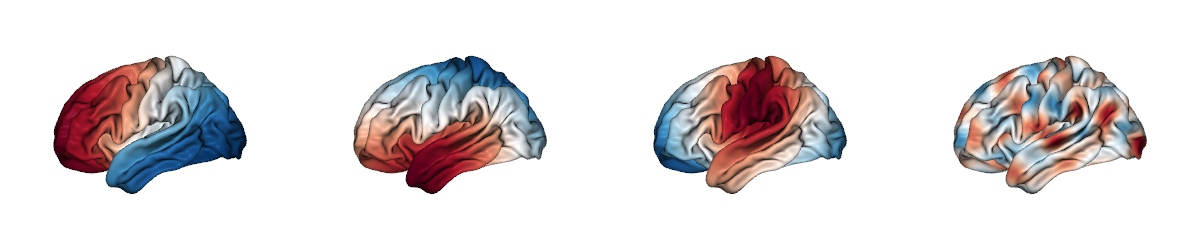

In [10]:
mode_ids = [1,2,3,99]
data_multi = {"lh": modes_unmasked[:, mode_ids]}

p = plot_surf(
    surfs, data=data_multi, rois=rois_parc, zoom=1, cmap="RdBu", views=["lateral"], size=(300, 250)
)
p.show()

By default, `plot_surf` sets the color range of each map to be `(np.nanmin(data), np.nanmax(data))`, but we can set the color range to whatever we would like by setting `clim` in one of two ways:
1. Set a global color range across all maps. This can be done by setting `clim` to be a 1D array with shape `(2,)` where the elements are (min, max).
2. Set a color range for each map individually. This can be done by in setting `clim` to be a 2D array with shape `(n_maps, 2)` where each row contains the min and max range for each map.

Here we set a global color limit across all maps.

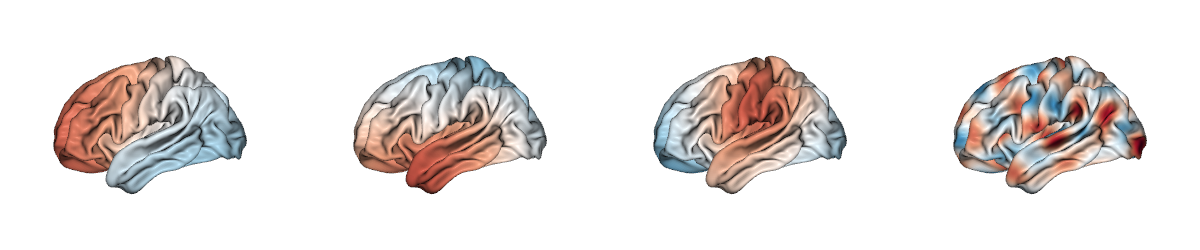

In [11]:
clim_group = (np.nanmin(modes_unmasked[:, mode_ids]), np.nanmax(modes_unmasked[:, mode_ids]))

p = plot_surf(
    surfs, data=data_multi, rois=rois_parc, zoom=1, cmap="RdBu", views=["lateral"], size=(300, 250), clim=clim_group
)
p.show()

Here we set an individual color range for each map where we restrict the color range to be just between the 2nd and 98th percentiles of the data. This can help improve visualisation of maps with wide data distributions.

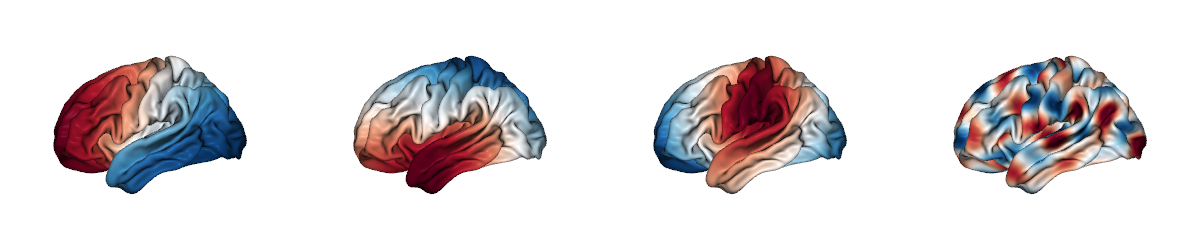

In [12]:
clim_indiv = np.vstack([np.nanpercentile(modes_unmasked[:, mode_ids], 2, axis=0), np.nanpercentile(modes_unmasked[:, mode_ids], 98, axis=0)]).T

p = plot_surf(
    surfs, data=data_multi, rois=rois_parc, zoom=1, cmap="RdBu", views=["lateral"], size=(300, 250), clim=clim_indiv
)
p.show()

So far we have only plotted the left hemisphere; however, we can plot both left and right hemispheres by setting both `"lh"` and `"rh"` key-value pairs to `surf`, `data`, and `rois`.

In [13]:
surf_rh_data, medmask_rh = fetch_surf(density=den, hemi="R", species=species)
surf_rh = {"vertices": surf_rh_data.vertices, "faces": surf_rh_data.faces}
surfs = {"lh": surf_lh, "rh": surf_rh}
rois = {"lh": medmask_lh, "rh": medmask_rh}

solver_rh = EigenSolver(surf_rh, medmask_rh)
solver_rh.solve(n_modes=100)
data = {
    "lh": unmask(solver_lh.emodes[:, 1], medmask_lh),
    "rh": unmask(solver_rh.emodes[:, 1], medmask_rh)
}

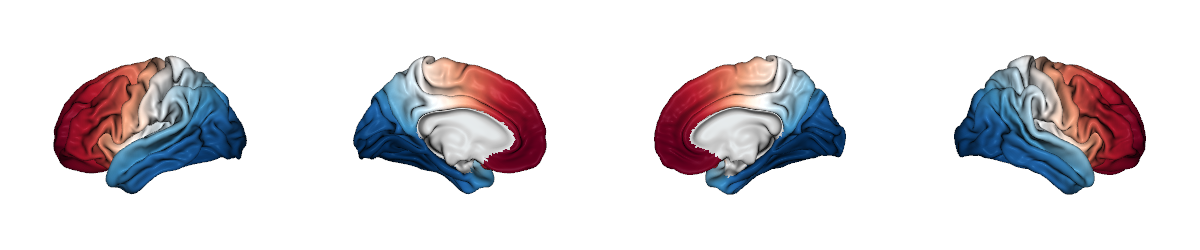

In [14]:
p = plot_surf(
    surfs, data=data, rois=rois, zoom=1, cmap="RdBu", views=["lateral", "medial"], size=(300, 250), 
)
p.show()

We can then add multiple views and change `layout_indiv` to adjust how the different views are arranged.

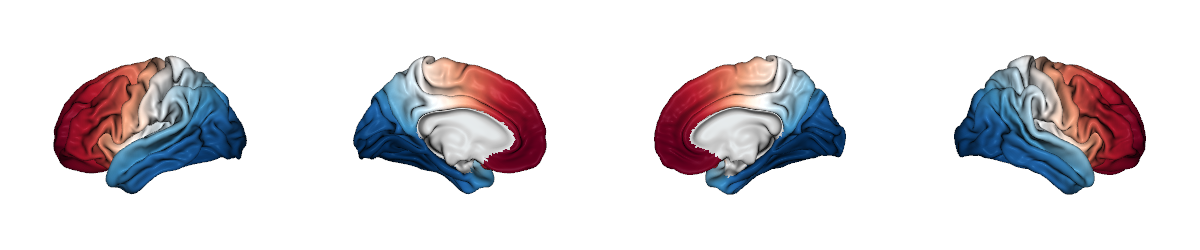

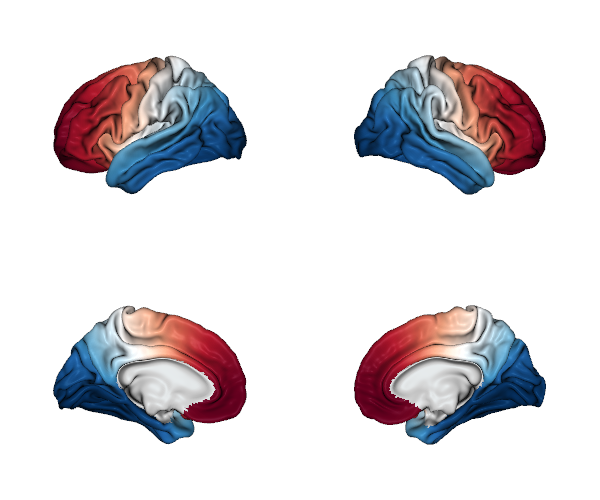

In [15]:
p1 = plot_surf(
    surfs, data=data, rois=rois, zoom=1, cmap="RdBu", views=["lateral", "medial"],
    size=(300, 250), layout_indiv="row" 
)
p1.show()

p2 = plot_surf(
    surfs, data=data, rois=rois, zoom=1, cmap="RdBu", views=["lateral", "medial"],
    size=(300, 250), layout_indiv="grid" 
)
p2.show()   

We can plot multiple maps (with multiple hemis and views) and define how they are globally arranged by using `layout_group`.

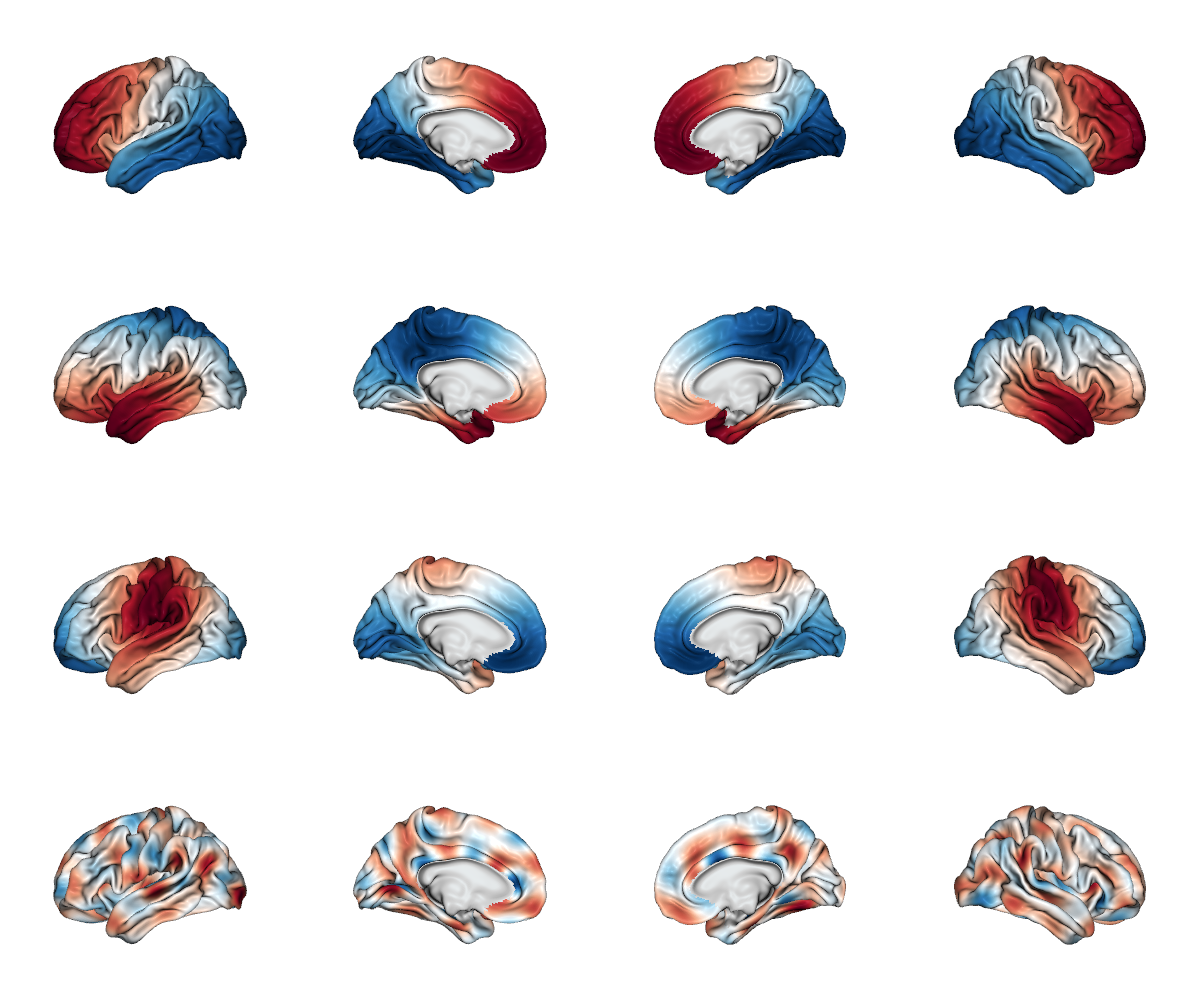

In [16]:
data = {
    "lh": unmask(solver_lh.emodes[:, mode_ids], medmask_lh), 
    "rh": unmask(solver_rh.emodes[:, mode_ids], medmask_rh)
}

p = plot_surf(
    surfs, data=data, rois=rois, zoom=1, cmap="RdBu", views=["lateral", "medial"],
    size=(300, 250), layout_indiv="row", layout_group="col",
)
p.show()

plot_surf always returns a plotly figure but we can optionally pass in a matplotlib axis using the ax argument in which case the figure will be converted to a static image and inserted into the axis. We can use the scale argument to increase the resolution.

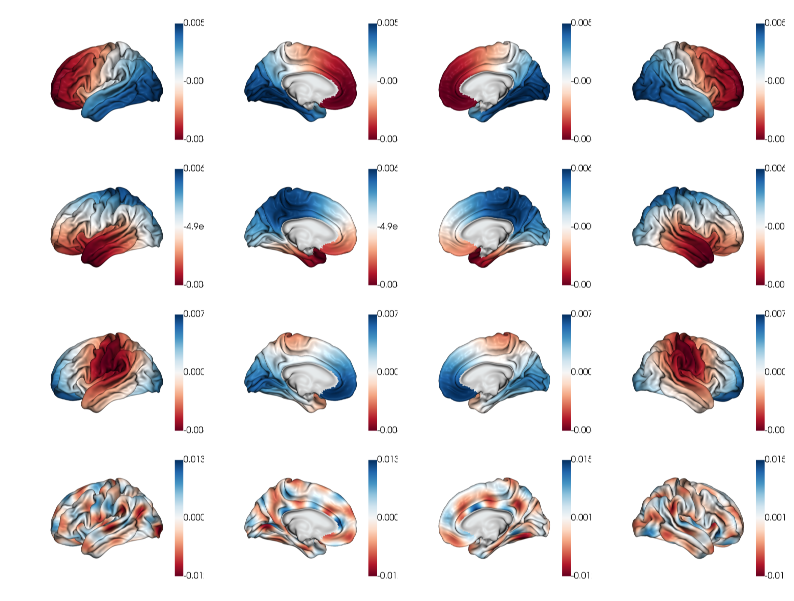

In [17]:
fig, ax = plt.subplots(figsize=(10, 10))

data = {
    "lh": unmask(solver_lh.emodes[:, mode_ids], medmask_lh), 
    "rh": unmask(solver_rh.emodes[:, mode_ids], medmask_rh)
}
p = plot_surf(
    surfs, data=data, rois=rois, zoom=1, cmap="RdBu", views=["lateral", "medial"], 
    layout_indiv="row", layout_group="col", ax=ax, cbar=True, scale=10
)

plt.show()